# Basic use of `lidar_hd_tools`

The `lidar_hd_tools` module aims to be a straight-forward way to get the LiDAR HD data. Only a few lines should be necessary to obtain what you want. As it is designed to download data, it requires an internet connection. As connections with APIs are established at the import, you will not be able to import the module without internet access.

Let's begin by importing the module:

In [1]:
import lidar_hd_tools as lhd

## Some checks before starting

We can check the version of the module and release date (you can clone the git repository if you want to update it easily using pulling requests):

In [2]:
lhd.__version__

'0.1.9'

It is important to check the folders that are set to collect the downloaded data. If you want to change them, you will have to edit the file `lidar_hd_tools/folders.json`.

In [3]:
lhd.current_folders()

DEM: /Volumes/THIBALT/downloaded/LIDARHD/tiles/DEM/
DSM: /Volumes/THIBALT/downloaded/LIDARHD/tiles/DSM/
lidar: /Volumes/THIBALT/downloaded/LIDARHD/tiles/lidar/


## Example with the Dolomieu crater (Reunion island)

### Creating a geodataframe

We don't have any `geopandas.GeoDataFrame` object at this point. But maybe we know the coordinates of a precise point. Then we can create a square of a certain size around this point using:

In [4]:
coordinates = {"lon": 55.70756, "lat": -21.24293}

dolomieu = lhd.geodataframe_from_coordinates(**coordinates, # latitude, longitude (WGS84 / EPSG:4326)
                                             size = 1500 # meters
                                             )
dolomieu

,geometry
0,"POLYGON ((55.70033 -21.23619, 55.71479 -21.236..."


### Simple download

Now, we can process to the downloading for this area. To download both the digital models and the 3D point cloud, we use the `lidar_hd_tools.download_data()` function. Some information about this function is given below:
- The only mandatory input is `gdf`, which has to be a `geopandas.GeoDataFrame` object with a defined coordinate reference system. First use `geopandas.GeoDataFrame.set_crs()` otherwise.
- A confirmation is asked if the selected area is large (by default for 10 or more different tiles to download, a tile is 2km$^2$). The `threshold_for_warning` parameter allows to change this threshold.
- The `build_dataset` parameter is `True` by default: it processes extra-layers derived from the digital models and outputs an `xarray.Dataset`. When it is set to `False`, the digital models are outputted as one `xarray.Dataset` object, as well as the 3D point cloud as a list of `laspy.lasdata.LasData` objects (length corresponding to the number of tiles downloaded).
- The `data_for_derivation` parameter defines which of the digital surface model (DSM) or the digital elevation model (DEM) is used to derive some layers such as the sky viewing factor, the slope gradient and aspect, etc. (default is `"DSM"`)
- The full resolution of the LIDAR-HD digital models is 0.5 m. Using the `decimation_factor` parameter, you can decimate the grids if you don't need this precision, as it can quickly become heavy in storage and computations. Please consider further reprojection and interpolation if you want to reach a resolution which cannot be found using decimation (e.g. 0.75 m, as only multiples of 0.5 can be reached). Default is `5` (2.5 m of resolution).
- The `lidar_decimation_factor` parameter allows to decimate the LIDAR point cloud with a randomized removal of the points. Default is `10`.
- To deactivate the printed loading bars and any prints relating the state of the process, set `verbose` to `False`.

Let's first set `build_dataset` to `False` and download the full resolution digital models (and 10-factor decimated point clouds). This library is not aiming to further process the point cloud, you can check the `laspy`documentation to see what is possible and eventually use other `.las`-compatible libraries strarting from the downloaded point clouds.

In [5]:
unbuilt_dataset, clouds = lhd.download_data(gdf = dolomieu, build_dataset=False, decimation_factor = 1)

Loading LiDAR data: 100%|██████████| 6/6 [00:12<00:00,  2.15s/it]


### Download and build

It is also possible to build the dataset. Then the point cloud will still be downloaded as it is used to retrieve a vegetation density layer (pt/pixel), but will not be outputted.

Here we look at the Dolomieu crater in Piton de la Fournaise, which is an active volcano located in the Reunion island (Indian Ocean). Thus, in such terrain, we use the DEM to derive interesting features, so `data_for_derivation='DEM'`. The DSM can be used, for instance, in urban context where we want to account for the buildings.

Finally, as we saw that the number of required tiles is pretty small, we can eventually not decimate the point cloud. Basically, decimation is useful for too heavy point clouds.

In [6]:
dataset = lhd.download_data(gdf = dolomieu,
                            decimation_factor = 5,  # 0.5 * 5 = 2.5 meters of resolution
                            lidar_decimation_factor = 1,
                            data_for_derivation="DEM")

Computing shadow: 100%|██████████| 144/144 [01:19<00:00,  1.82it/s]


Computing DHM, SVF, slope gradient, slope aspect...


Computing vegetation cover density map: 100%|██████████| 67212/67212 [00:00<00:00, 96275.73it/s] 


Compressed, 0.07 GB -> 0.06 GB


### Visualisation

Now, let's do some visualisation of our data. The `lidar_hd_tools.visualisation` module provides basic functions to plot the data. The `plot_dataset` function allows to plot any chosen layer of the dataset (`layer` parameter). A `cartopy.mpl.geoaxes.GeoAxes` axis can be passed as `ax` parameter, otherwise it is created. The `gridlines` boolean allows to plot or hide the gridlines corresponding to the geographic coordinates. Finally, kwargs can be passed as they would be passed to the `xarray.DataArray.plot.pcolormesh()` function.

The outputted object are the created or used `cartopy.mpl.geoaxes.GeoAxes` axis and the plotted `matplotlib.collections.QuadMesh` object.

In [7]:
from lidar_hd_tools import visualisation as vis
import matplotlib.pyplot as plt
from cartopy.crs import PlateCarree # to plot WGS84

We managed to download our DSM and DEM at the highest resolution, so we would use `unbuilt_dataset` to plot them.


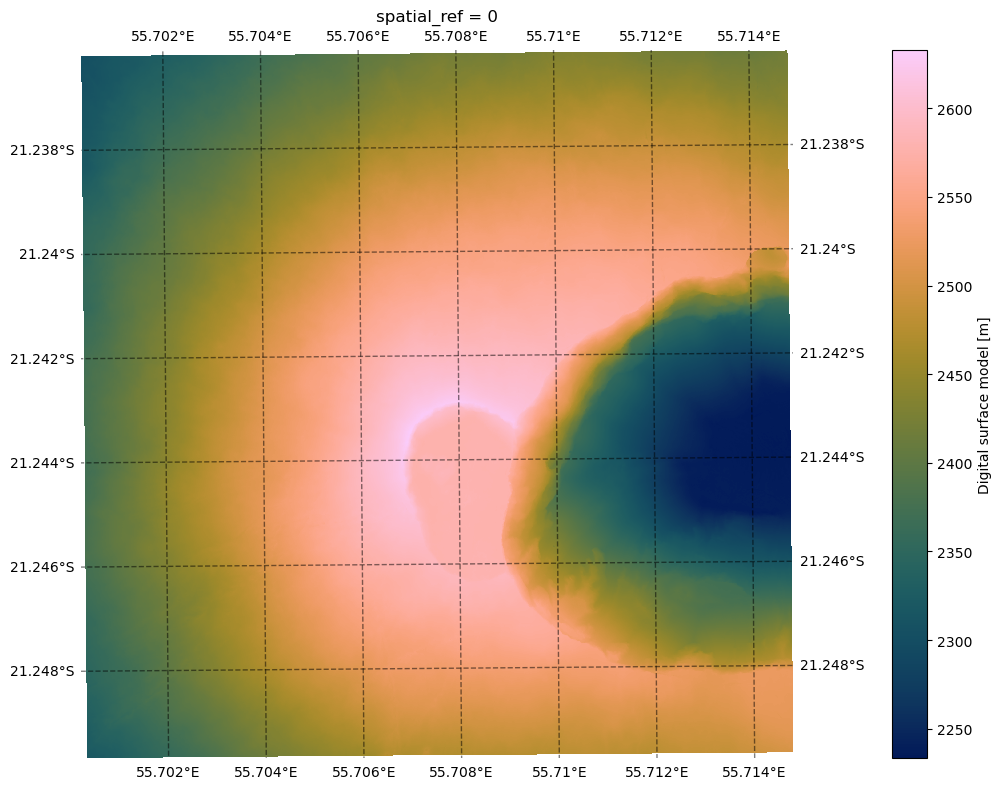

In [8]:
ax, quadmesh = vis.plot_dataset(unbuilt_dataset, "DSM")
plt.show()

As you can see the layers have predefined options for plotting. You can overwrite those parameters if you prefer to put yours:

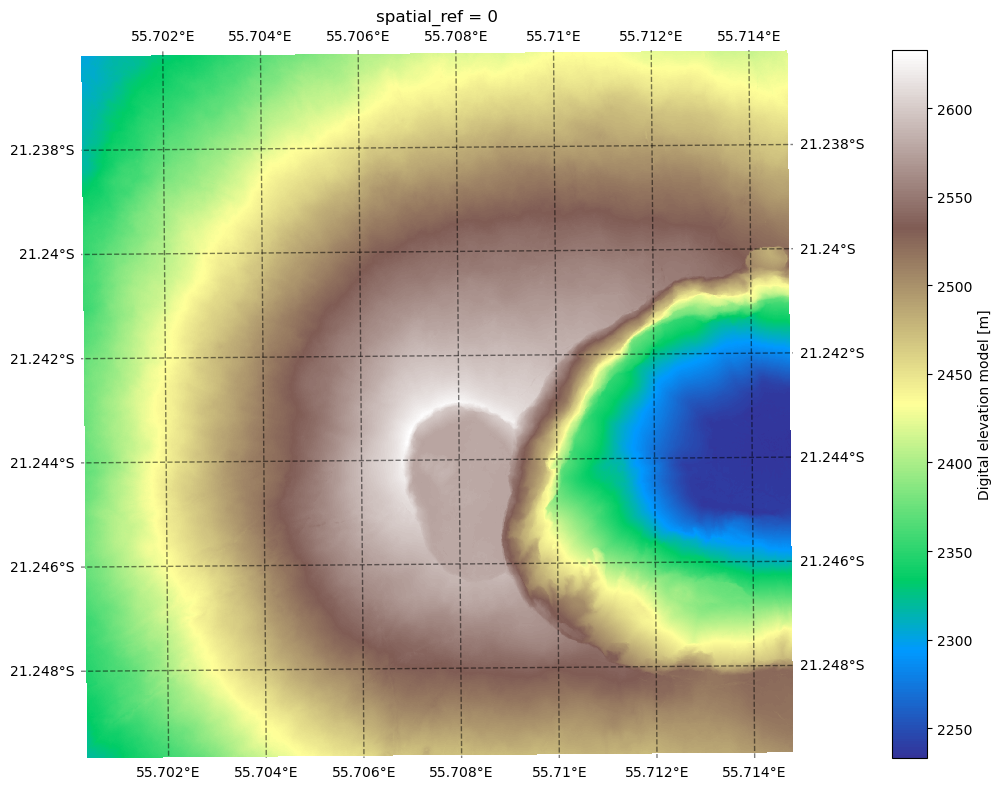

In [9]:
ax, quadmesh = vis.plot_dataset(unbuilt_dataset, "DEM", cmap="terrain")
plt.show()

As illustrated in the sky-view factor plot below, you can remove the gridlines to better observe the scene. If you want to add features to your `ax` object, don't forget it is projected in local coordinates, so you should use `cartopy.crs.PlateCaree()` transform to include features in geographic coordinates.

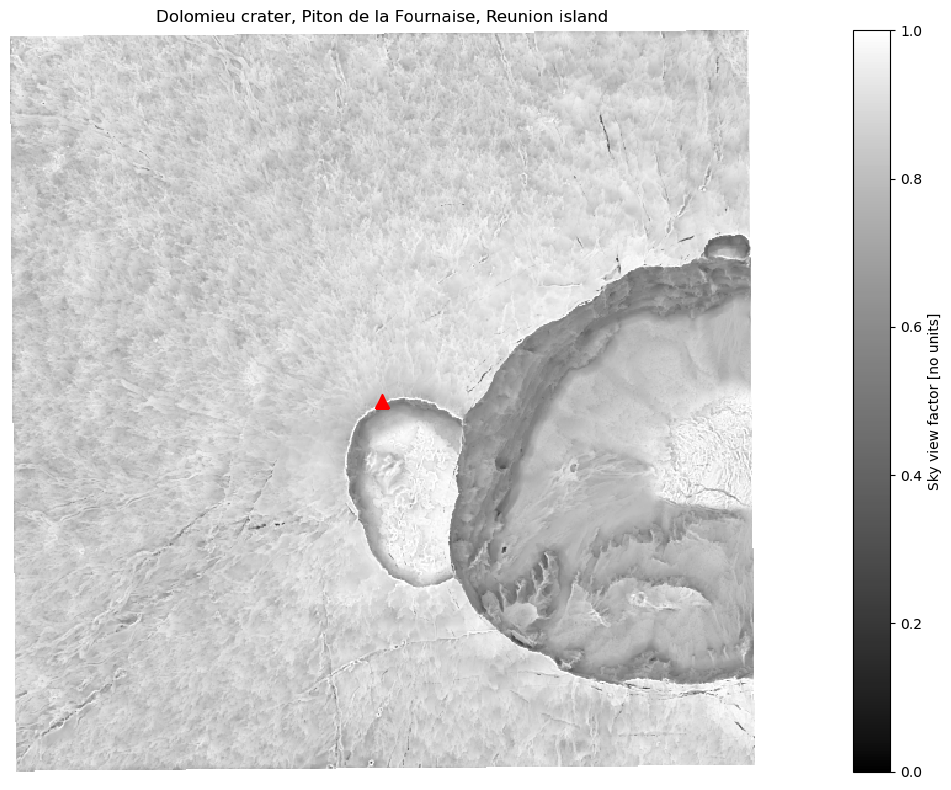

In [10]:
ax, quadmesh = vis.plot_dataset(dataset, "SVF", gridlines=False)
ax.set_title("Dolomieu crater, Piton de la Fournaise, Reunion island")
ax.scatter(coordinates["lon"],coordinates["lat"], transform=PlateCarree(), color="r", marker="^", s=100)
plt.show()

Using `xarray.Dataset.where()` function, it is easy to superimpose layers as illustrated here:

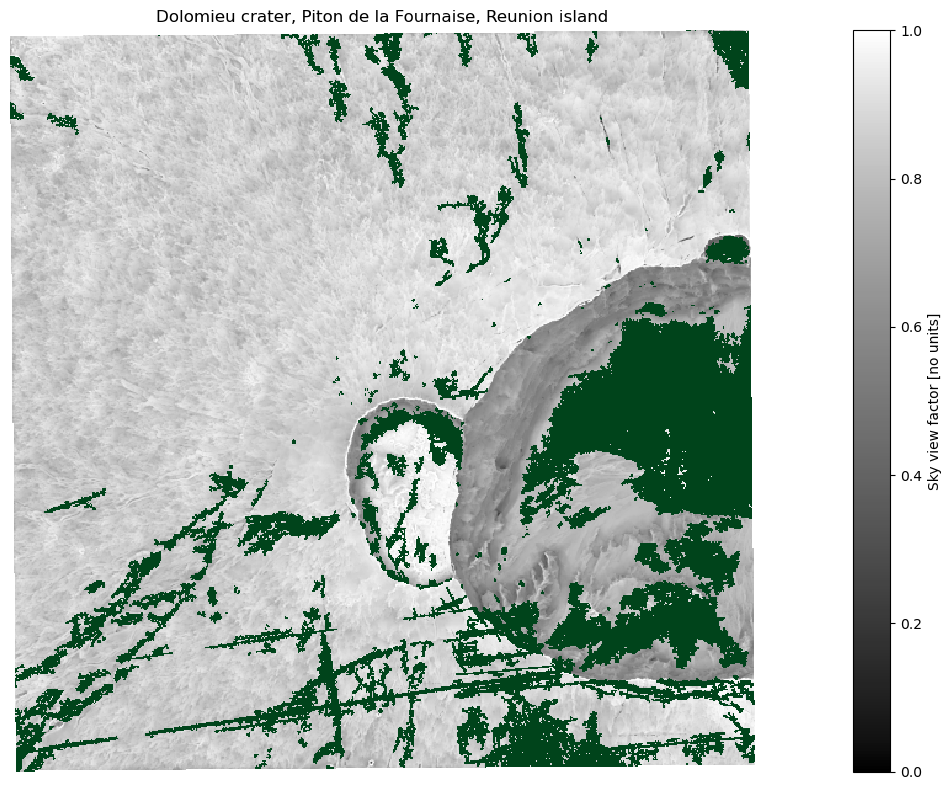

In [11]:
vegetated = dataset.where(dataset.vegetation > 0)

ax, quadmesh = vis.plot_dataset(dataset, "SVF", gridlines=False)
ax, quadmesh = vis.plot_dataset(vegetated, "vegetation", vmax=1, ax=ax, add_colorbar=False, gridlines=False)
ax.set_title("Dolomieu crater, Piton de la Fournaise, Reunion island")
plt.tight_layout()
plt.show()

Here is an illustrated example of use of an external `ax`, note that it needs to have a `cartopy.crs` projection to be compatible, otherwise an exception will be raised. The `lidar_hd_tools.visualisation.get_projection()` function allows to convert easily the CRS of the dataset into such object.

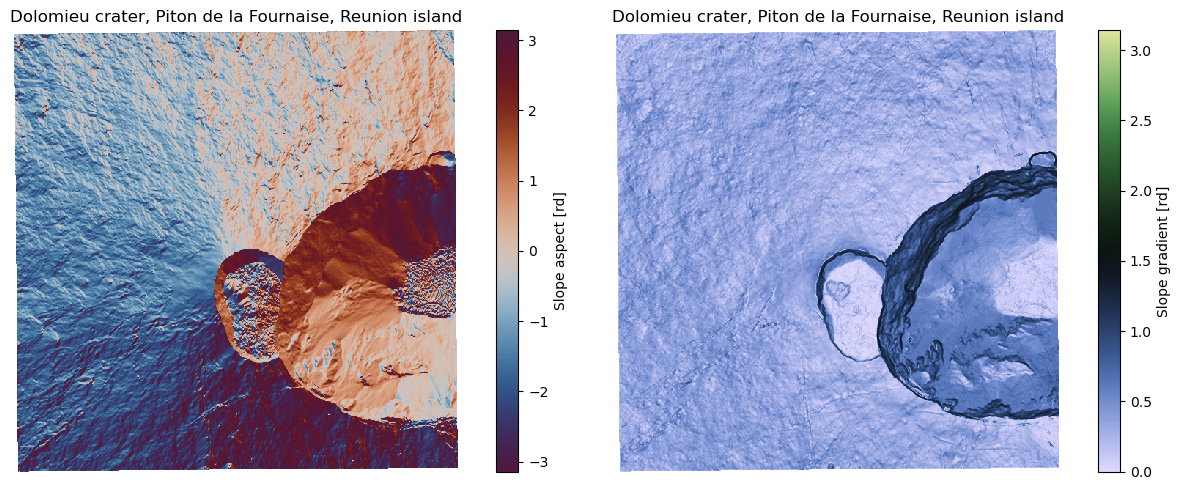

In [12]:
fig, axes = plt.subplots(1,2, figsize=(14,5), subplot_kw={"projection":vis.get_projection(dataset.rio.crs)})

ax, quadmesh = vis.plot_dataset(dataset, "aspect", ax=axes[0], gridlines=False)
ax.set_title("Dolomieu crater, Piton de la Fournaise, Reunion island")

ax, quadmesh = vis.plot_dataset(dataset, "slope_grad", ax=axes[1], gridlines=False)
ax.set_title("Dolomieu crater, Piton de la Fournaise, Reunion island")

plt.show()

Layers that contains other dimensions than `x` and `y` are raising an exception when inputed. This is typically the case for the shadow, which is computed for different sun positions. It is then necessary to reduce the dimension, using `xarray.Dataset.sel()` or `xarray.Dataset.isel()` functions. Note that boolean layers are hiding the `False` pixels.

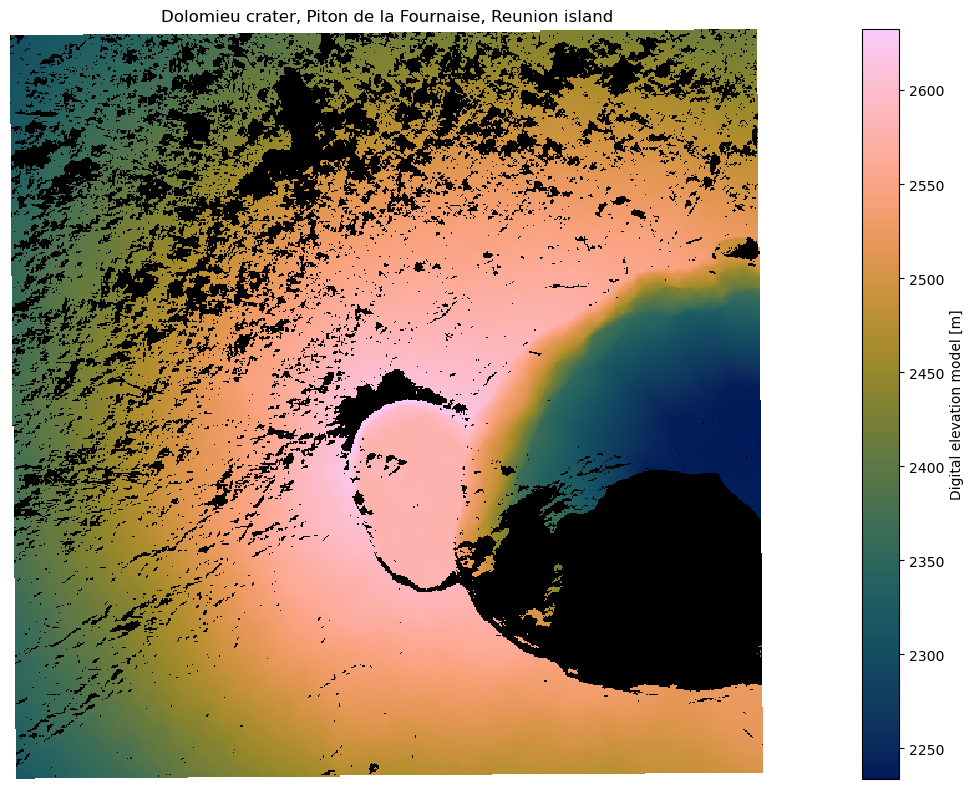

In [13]:
ax, quadmesh = vis.plot_dataset(dataset, "DEM", gridlines=False)
ax, quadmesh = vis.plot_dataset(dataset.sel(sun_elevation=45).sel(sun_azimuth=157.5), "shadow", gridlines=False, ax=ax)
ax.set_title("Dolomieu crater, Piton de la Fournaise, Reunion island")
plt.show()

### Ortho-image from BD-ORTHO

It is possible to add an ortho-image from IGN's BD-ORTHO product at the resolution of the `dataset`/`unbuilt_dataset` using the `lidar_hd_tools.get_orthoimage()` function.`:

In [14]:
unbuilt_dataset = lhd.get_orthoimage(unbuilt_dataset)

The `lidar_hd_tools.visualisation.plot_orthophoto()` function can be used to visualise it. It takes as extra-input the same `ax` argument as the `lidar_hd_tools.visualisation.plot_dataset()` function.

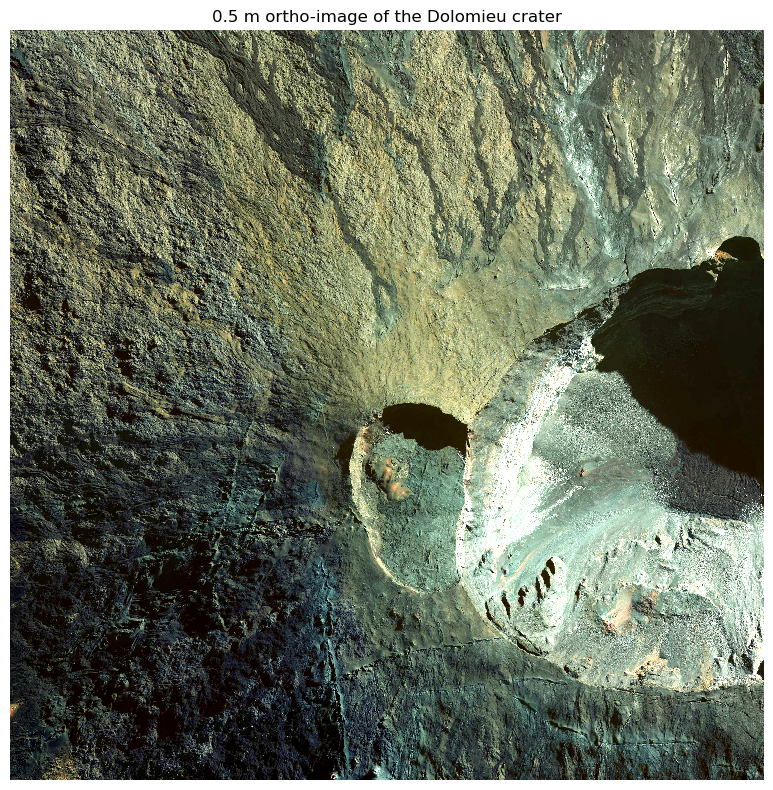

In [15]:
ax = lhd.visualisation.plot_orthophoto(unbuilt_dataset)
ax.set_title(f"{unbuilt_dataset.rio.resolution()[0]:.1f} m ortho-image of the Dolomieu crater")
plt.show()

## Example with the 1st district of Lyon

Here is an example to illustrate the use of `lidar_hd_tools` in urban context. We won't explain again the used functions when mentionned upper, please refer to the previous section for explanations.

We do have this time a `geopandas.GeoDataFrame` object:

In [16]:
import pickle; lyon = pickle.load(open("example_geodata.pkl", "rb"))

In [17]:
urban_dataset = lhd.download_data(lyon)

Computing shadow: 100%|██████████| 144/144 [01:09<00:00,  2.06it/s]


Computing DHM, SVF, slope gradient, slope aspect...


Computing vegetation cover density map: 100%|██████████| 111517/111517 [00:01<00:00, 96723.10it/s] 


Compressed, 0.07 GB -> 0.07 GB


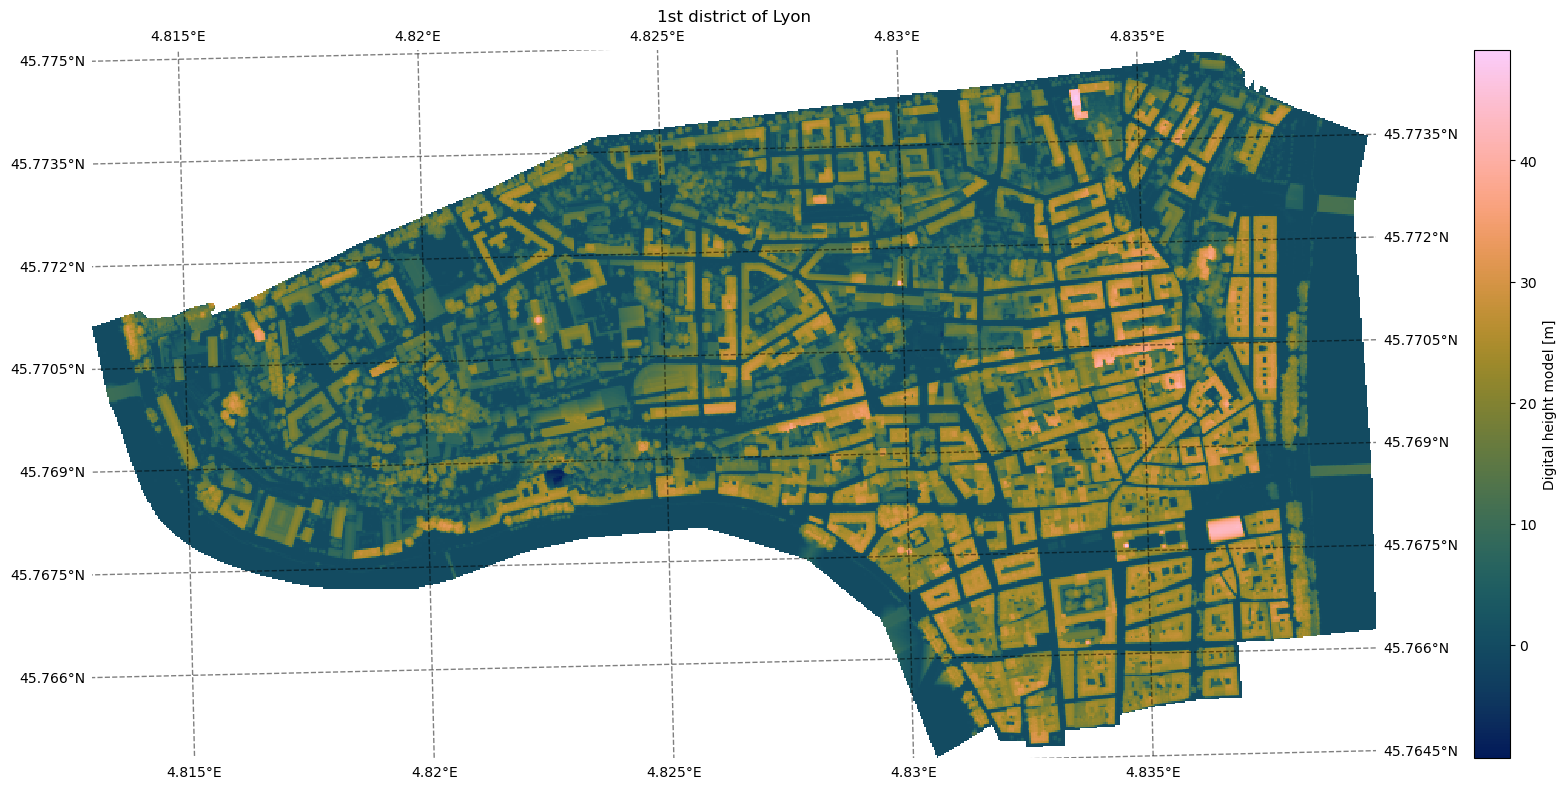

In [18]:
ax, quadmesh = vis.plot_dataset(urban_dataset, "DHM")
ax.set_title("1st district of Lyon")
plt.show()

One other capability of `lidar_hd_tools` is its ability to use IGN's BD-TOPO product. Using `lidar_hd_tools.get_buildings_mask()` and `lidar_hd_tools.get_water_mask()`, you can find both buildings and water areas with high precision, that will be rasterised to your `dataset` object's resolution.

In [19]:
urban_dataset = lhd.get_buildings_mask(urban_dataset)
urban_dataset = lhd.get_water_mask(urban_dataset)

Loading buildings from BD-TOPO: 100%|██████████| 43/43 [00:26<00:00,  1.64it/s]


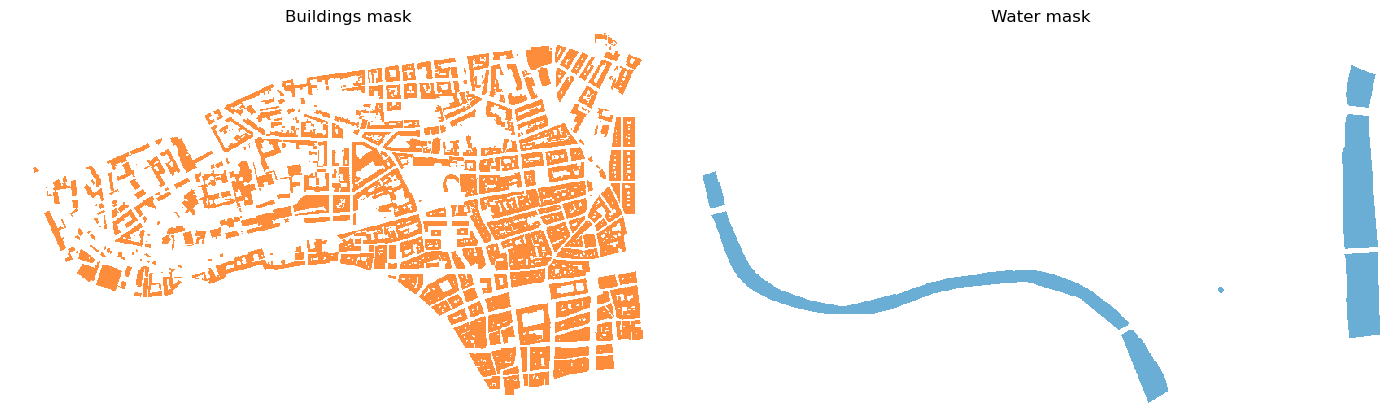

In [20]:
fig, axes = plt.subplots(1,2, figsize=(14,5), subplot_kw={"projection":vis.get_projection(urban_dataset.rio.crs)})

ax, quadmesh = vis.plot_dataset(urban_dataset, "buildings_mask", ax=axes[0], gridlines=False)
ax.set_title("Buildings mask")

ax, quadmesh = vis.plot_dataset(urban_dataset, "water_mask", ax=axes[1], gridlines=False)
ax.set_title("Water mask")

plt.show()

Finally, it is possible to use the OCS-GE product of IGN to get simplified land cover, using the `lidar_hd_tools.get_land_occupation()` function. Note that the computed `water_mask` layer is overwriting the previously acquired water mask from BD-TOPO.

In [21]:
urban_dataset = lhd.get_land_occupation(urban_dataset)

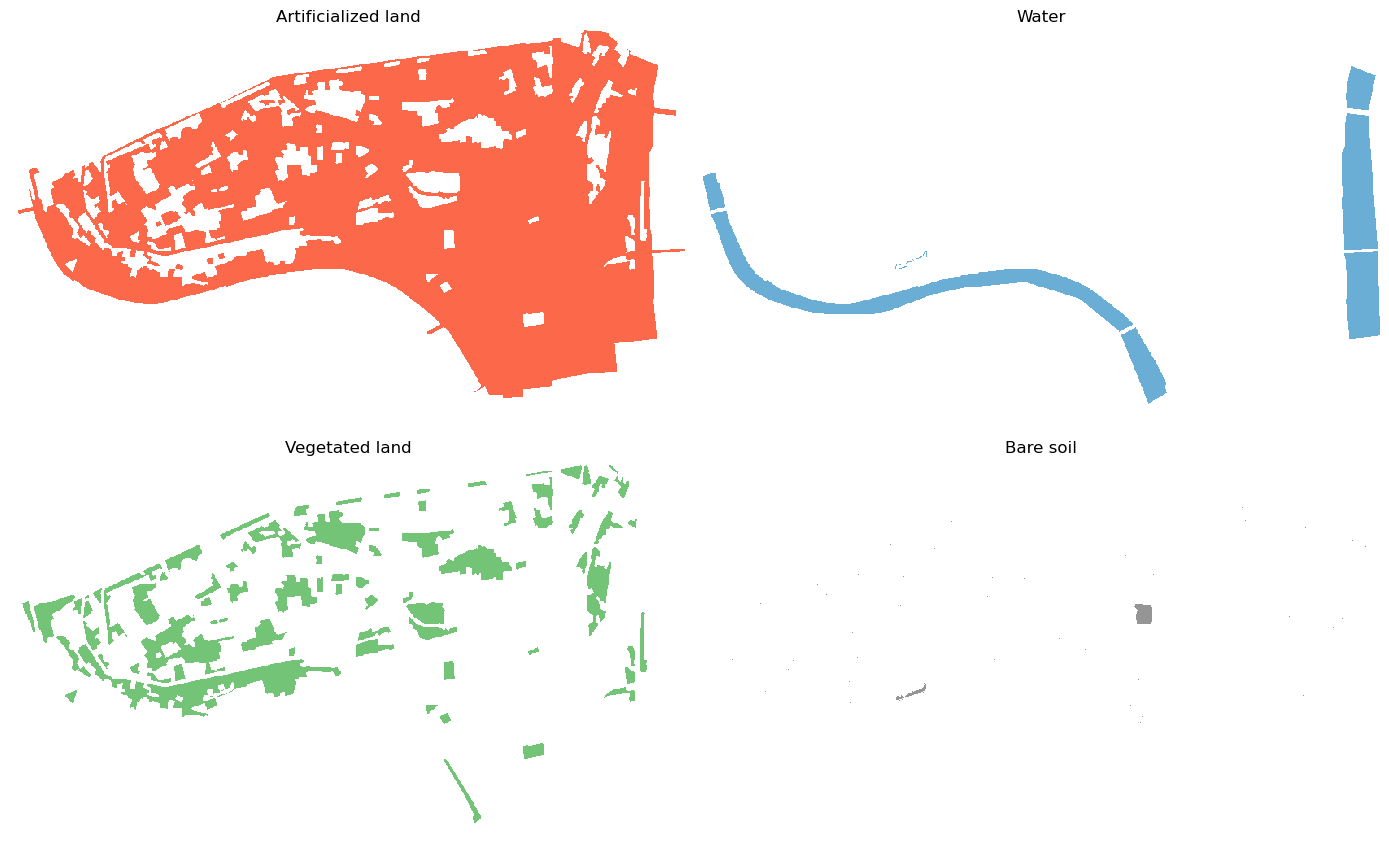

In [22]:
fig, axes = plt.subplots(2,2, figsize=(14,10), subplot_kw={"projection":vis.get_projection(urban_dataset.rio.crs)})

ax, quadmesh = vis.plot_dataset(urban_dataset, "artificial", ax=axes[0,0], gridlines=False)
ax.set_title("Artificialized land")

ax, quadmesh = vis.plot_dataset(urban_dataset, "water_mask", ax=axes[0,1], gridlines=False)
ax.set_title("Water")

ax, quadmesh = vis.plot_dataset(urban_dataset, "vegetalized", ax=axes[1,0], gridlines=False)
ax.set_title("Vegetated land")

ax, quadmesh = vis.plot_dataset(urban_dataset, "mineralized", ax=axes[1,1], gridlines=False)
ax.set_title("Bare soil")

plt.show()

To end up, here is some esthetic map of the urban landscape of the center of Lyon.

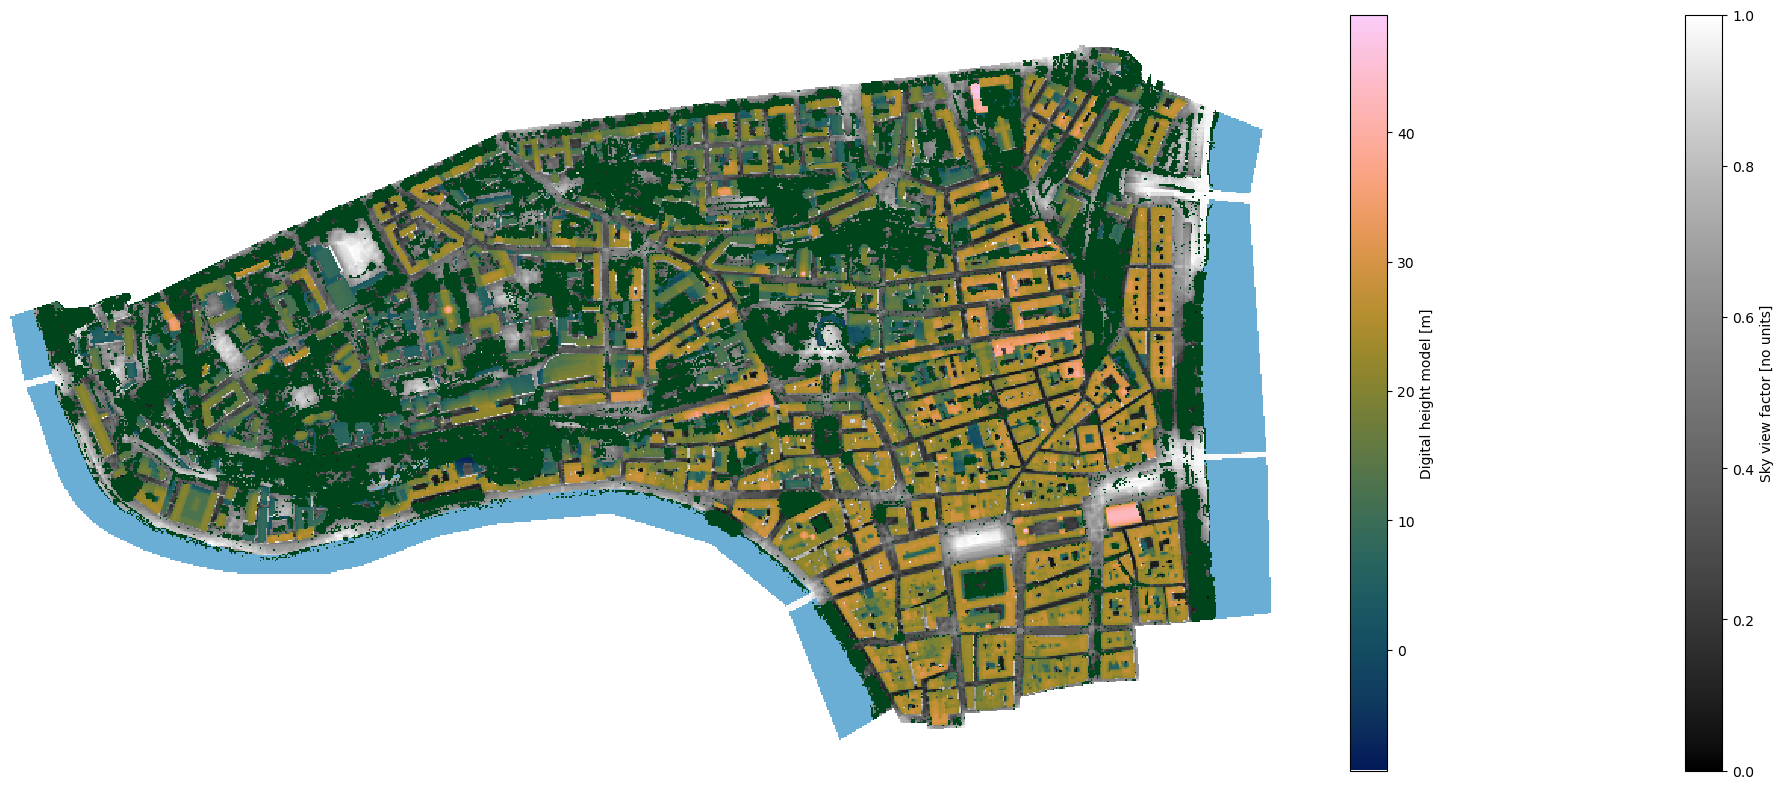

In [23]:
buildings = urban_dataset.where(urban_dataset.buildings_mask)
vegetation = urban_dataset.where(urban_dataset.vegetation>0)

ax, quadmesh = vis.plot_dataset(urban_dataset, "SVF", gridlines=False)
ax, quadmesh = vis.plot_dataset(buildings, "DHM", ax=ax, gridlines=False)
ax, quadmesh = vis.plot_dataset(urban_dataset, "water_mask", ax=ax, gridlines=False)
ax, quadmesh = vis.plot_dataset(vegetation, "vegetation", ax=ax, gridlines=False, vmax=1, add_colorbar=False)
ax.set_title("")
plt.show()

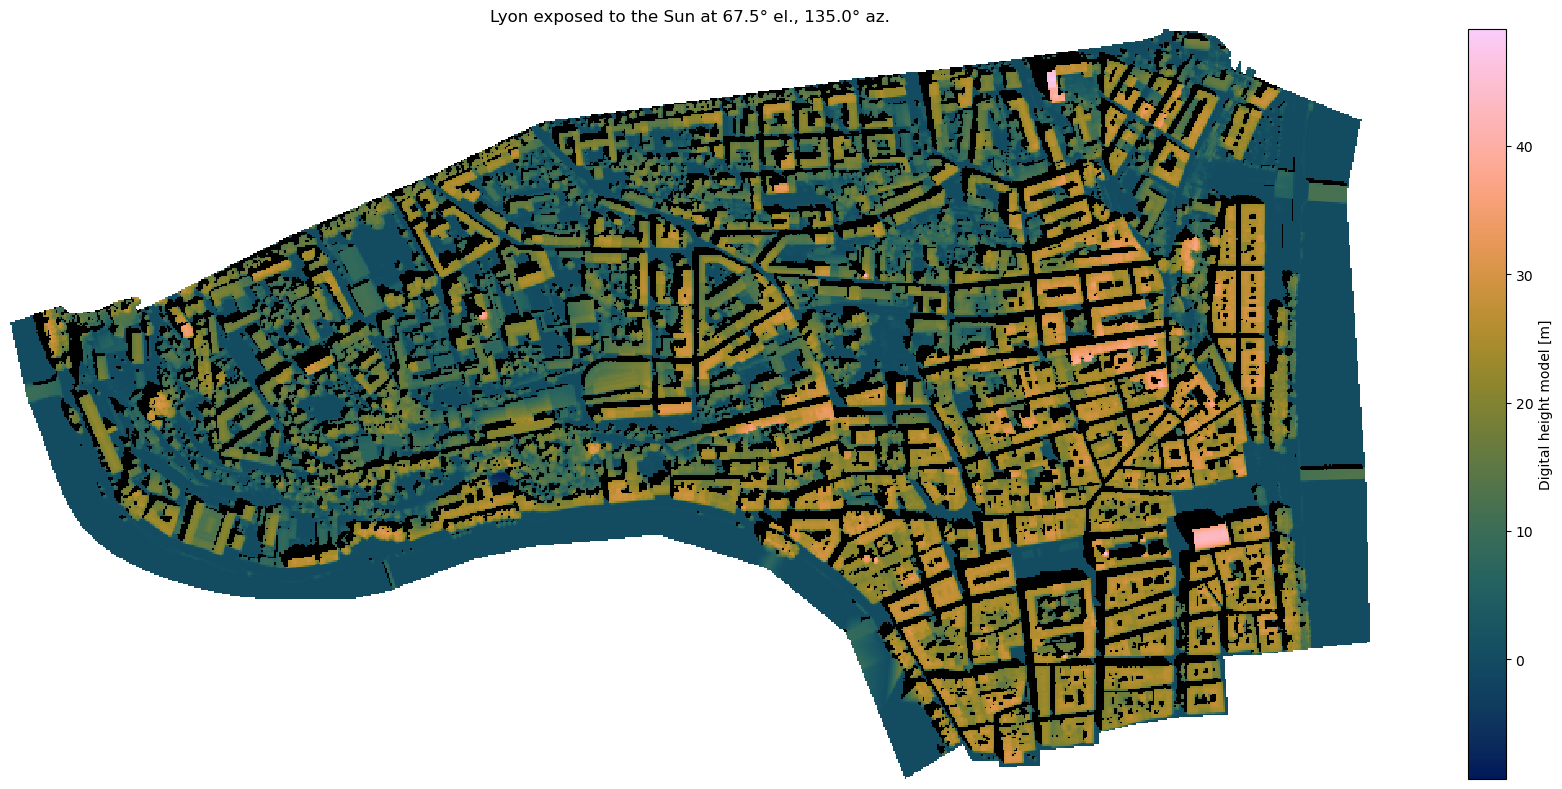

In [24]:
shadow = urban_dataset.sel(sun_elevation=67.5, sun_azimuth=135)

ax, quadmesh = vis.plot_dataset(urban_dataset, "DHM", gridlines=False)
ax, quadmesh = vis.plot_dataset(shadow, "shadow", ax=ax, gridlines=False)
ax.set_title(f"Lyon exposed to the Sun at {shadow.sun_elevation.values}° el., {shadow.sun_azimuth.values}° az.")
plt.show()